# Exercise 4

In [122]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math

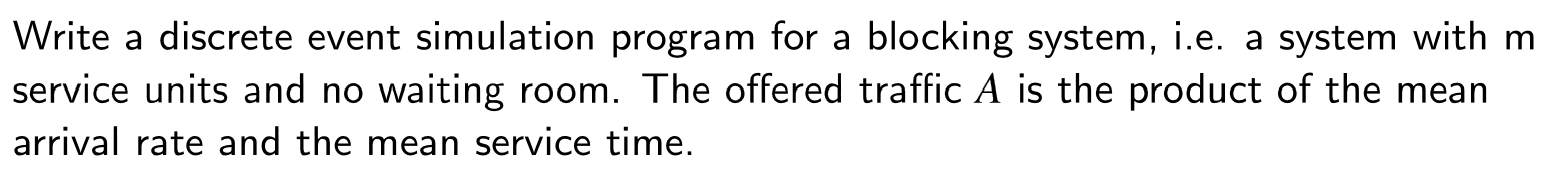

## Part 1


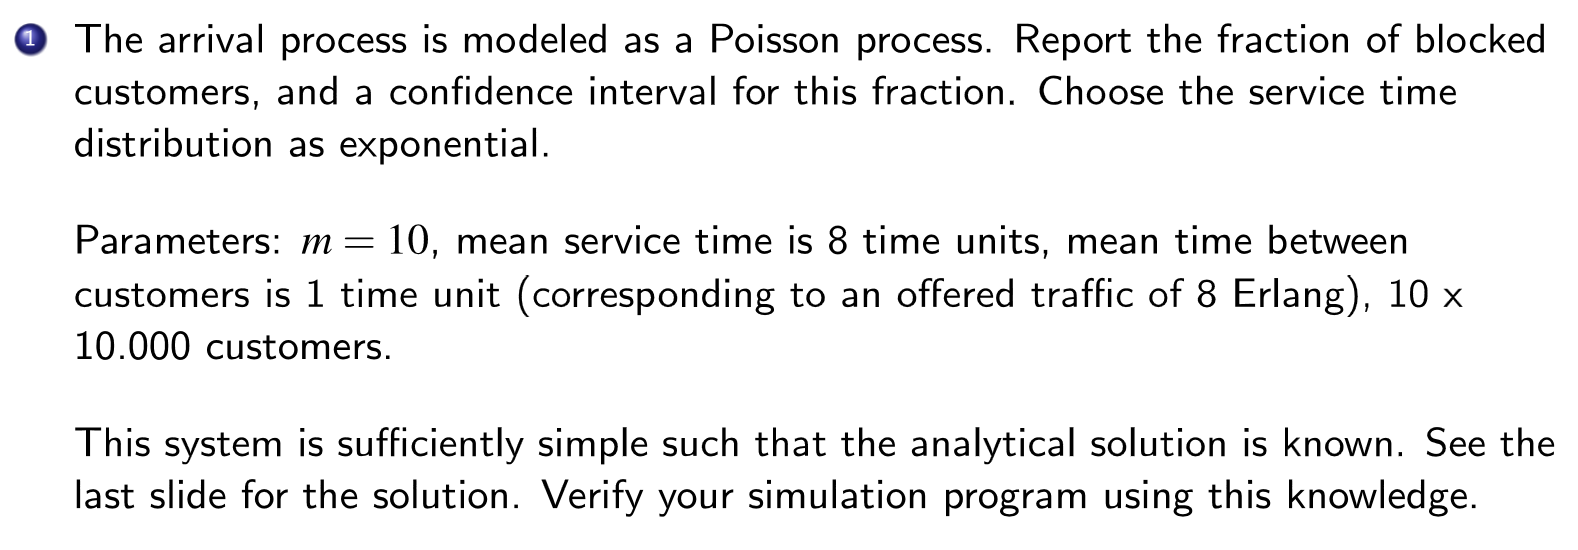

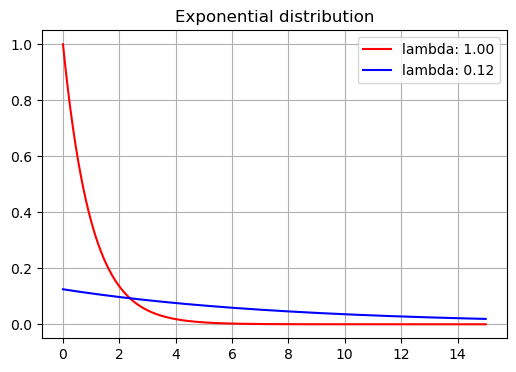

In [145]:
### Plotting exponential distribution

xgrid = np.linspace(0,15,1000)

lambda1 = 1/1
lambda2 = 1/8


#Create figure
fig, axs = plt.subplots(1,1, figsize=(6,4))

axs.plot(xgrid, sp.stats.expon.pdf(xgrid, scale=1/lambda1), label=f'lambda: {lambda1:.2f}', color='red')
axs.plot(xgrid, sp.stats.expon.pdf(xgrid, scale=1/lambda2), label=f'lambda: {lambda2:.2f}', color='blue')

axs.legend()
axs.grid()
axs.set_title("Exponential distribution")

plt.show()

#### Exact solution

In [138]:
### Erlang's B forumula

def Erlang_B(m, lamd, s):
    A = lamd*s

    sum = 0
    for i in range(0,m+1):
        sum += A**i / math.factorial(i)

    numerator = A**m / math.factorial(m)

    return numerator/sum


lambd = 1/1
s = 8
m = 10

B = Erlang_B(m, lambd, s)
print(f"B: {B:.4f}")

B: 0.1217


In [ ]:
def block_system_poisson(n_customers=1e4, n_subsamples=10, t_mean_service=8, t_mean_customers=1):

    # Initialise result lists
    t_res = []
    blocked_frac_res = []
    departures_res =  []

    #loop over subsamples
    for _ in range(n_subsamples):
        #State variables
        departures = []              #list of departure times for custormers currently being serviced 
        count_blocked = 0           #Counter for blocked customers
        t = 0                       #clock time
        t_arrival = 0               #arrival time (initialise as zero)

        # loop through all customers encounters
        for _ in range(int(n_customers)):
            #update time
            t += t_arrival

            #Update departure list if not empty: keep only customers in list, whose departure time > current time
            if len(departures) != 0:
                departures = [dep for dep in departures if dep > t]

            #Check whether capacity full. 
            # If full, block customer
            if len(departures) >= 10:
                count_blocked += 1                                      #increase block counter
            #If not full, assign service time and add customer to departure list
            else:
                #Assign service time for current customer
                t_service = np.random.exponential(t_mean_service)      #NB: np.randdom.exp takes mean as param
                #Add customers departure time to departure list
                departures.append(t+t_service)

            #Assign arrival time to next costumer
            t_arrival = np.random.exponential(t_mean_customers)
        
        #Store results
        t_res.append(t)
        blocked_frac_res.append(count_blocked/n_customers)
        departures_res.append(departures)

    return np.array(blocked_frac_res), np.array(t_res), departures_res

In [129]:
### Run simulation
blocked_frac_res, t_res, departures_res = block_system_poisson(
    n_customers=1*1e4, n_subsamples=10, t_mean_service=8, t_mean_customers=1)

### Check results

res_idx = 0
print("Resutls for blocked fraction:")
print(blocked_frac_res)
print("Resutls for total time:")
print(t_res)
print("Resutls customers in departure list in the end:")
print(departures_res[res_idx])

Resutls for blocked fraction:
[0.1275 0.1255 0.1312 0.1237 0.1137 0.1207 0.1237 0.131  0.1255 0.1187]
Resutls for total time:
[ 9986.87745178  9816.13470905  9908.86711585 10009.45499556
 10050.18733057 10099.20220597  9982.0412282   9994.6994371
 10028.60672351 10068.60840228]
Resutls customers in departure list in the end:
[9991.694167800611, 9989.36790441987, 10013.784563995916, 10005.965727708604, 10013.532097513134, 9995.802645604375, 9989.581059621481, 9987.480073438006, 9998.675907801458]


In [139]:
### Compute conficdence interval

def confidence_interval(estimator, alpha):

    #sample size
    n=len(estimator)

    #estimate mean
    mean = np.mean(estimator)
    var = np.var(estimator, ddof=1)
    stddev = np.sqrt(var)

    #Degrees of freedom
    df=n-1

    #computing test statistic
    t_lower = sp.stats.t.ppf(q=alpha/2, df=df)
    t_upper = sp.stats.t.ppf(q=1-alpha/2, df=df)

    conf_lower = mean + stddev/np.sqrt(n) * t_lower
    conf_upper = mean + stddev/np.sqrt(n) * t_upper

    return mean, conf_lower, conf_upper


b_mean, b_conf_lower, b_conf_upper = confidence_interval(blocked_frac_res, alpha=0.05)

print(f"Result mean: {b_mean:.4f}")
print(f"Result confidence interval: {b_conf_lower:.4f}, {b_conf_upper:.4f}")
print("theoretical result is within own interval!")

Result mean: 0.1241
Result confidence interval: 0.1203, 0.1280
theoretical result is within own interval!


## Part 2

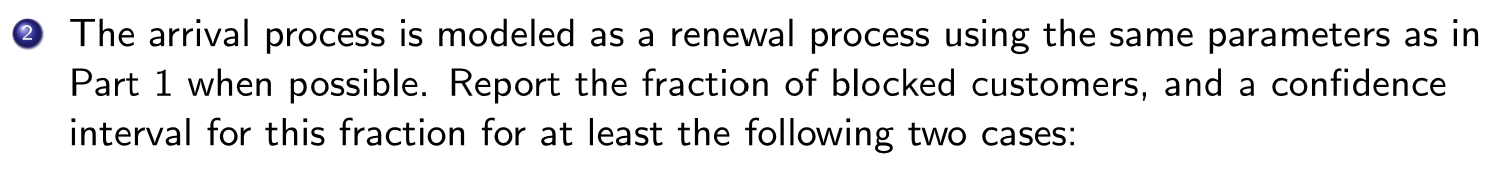

### A)

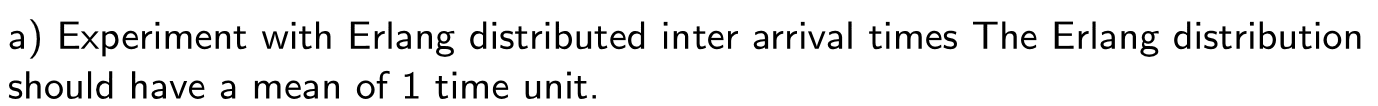

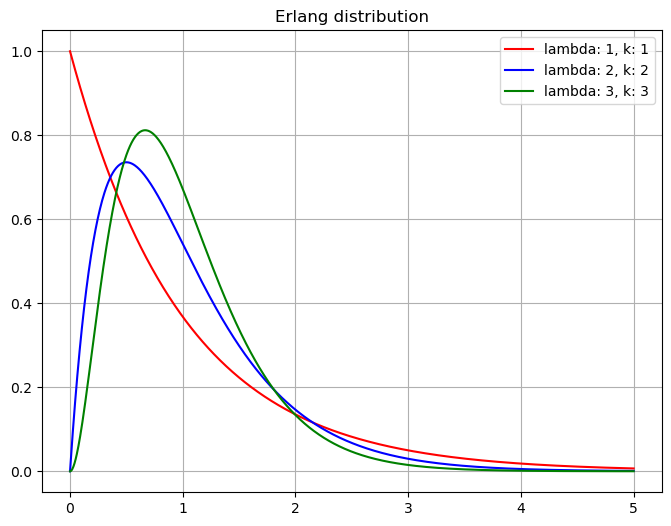

In [156]:
### Plotting Erlang distribution

#Mean for Erlang dits:  mean = k/lambda 
#NB: in scipy: 'scale' = 1/lambda,   'shape parameter', k: a

#Mean for Erlang dist.:  mean = k/lambda = k*scale

#Chosing param-combinations with mean=1
lambda1 = 1
k1 = 1
lambda2 = 2
k2 = 2
lambda3 = 3
k3 = 3

xgrid = np.linspace(0,5,1000)

#Create figure
fig, axs = plt.subplots(1,1, figsize=(8,6))

axs.plot(xgrid, sp.stats.erlang.pdf(xgrid, a=k1, scale=1/lambda1), label=f'lambda: {lambda1}, k: {k1}', color='red')
axs.plot(xgrid, sp.stats.erlang.pdf(xgrid, a=k2, scale=1/lambda2), label=f'lambda: {lambda2}, k: {k2}', color='blue')
axs.plot(xgrid, sp.stats.erlang.pdf(xgrid, a=k3, scale=1/lambda3), label=f'lambda: {lambda3}, k: {k3}', color='green')

axs.legend()
axs.grid()
axs.set_title("Erlang distribution")

plt.show()

Re-write previous function, by changing the distribution for the interarrival times

In [161]:
def block_system_erlang(n_customers=1e4, n_subsamples=10, t_mean_service=8, t_mean_customers=1):

    # Initialise result lists
    t_res = []
    blocked_frac_res = []
    departures_res =  []

    #loop over subsamples
    for _ in range(n_subsamples):
        #State variables
        departures = []              #list of departure times for custormers currently being serviced 
        count_blocked = 0           #Counter for blocked customers
        t = 0                       #clock time
        t_arrival = 0               #arrival time (initialise as zero)

        # loop through all customers encounters
        for _ in range(int(n_customers)):
            #update time
            t += t_arrival

            #Update departure list if not empty: keep only customers in list, whose departure time > current time
            if len(departures) != 0:
                departures = [dep for dep in departures if dep > t]

            #Check whether capacity full. 
            # If full, block customer
            if len(departures) >= 10:
                count_blocked += 1                                      #increase block counter
            #If not full, assign service time and add customer to departure list
            else:
                #Assign service time for current customer
                t_service = np.random.exponential(t_mean_service)      #NB: np.randdom.exp takes mean as param
                #Add customers departure time to departure list
                departures.append(t+t_service)

            #Assign arrival time to next costumer (erlang)
            t_arrival = sp.stats.erlang.rvs(a=2, scale=1/2)
        
        #Store results
        t_res.append(t)
        blocked_frac_res.append(count_blocked/n_customers)
        departures_res.append(departures)

    return np.array(blocked_frac_res), np.array(t_res), departures_res

In [162]:
### Run simulation
blocked_frac_erl, t_erl, departures_erl = block_system_erlang(
    n_customers=1*1e4, n_subsamples=10, t_mean_service=8, t_mean_customers=1)

### Check results

res_idx = 0
print("Resutls for blocked fraction:")
print(blocked_frac_erl)
print("Resutls for total time:")
print(t_erl)
print("Resutls customers in departure list in the end:")
print(departures_erl[res_idx])

Resutls for blocked fraction:
[0.0967 0.096  0.0845 0.0991 0.0938 0.094  0.0988 0.0884 0.0915 0.0899]
Resutls for total time:
[10054.11254203  9967.95771477 10066.60001663  9932.70103158
  9940.02360439  9917.25072846 10000.44879735  9988.26515267
 10101.28937365  9990.05555739]
Resutls customers in departure list in the end:
[10057.164790811572, 10064.487533148807, 10086.654529045505, 10075.548259715766, 10061.324889601383]


In [163]:
b_mean, b_conf_lower, b_conf_upper = confidence_interval(blocked_frac_erl, alpha=0.05)

print(f"Result mean: {b_mean:.4f}")
print(f"Result confidence interval: {b_conf_lower:.4f}, {b_conf_upper:.4f}")
print("theoretical result is within own interval!")

Result mean: 0.0933
Result confidence interval: 0.0899, 0.0966
theoretical result is within own interval!


### B)

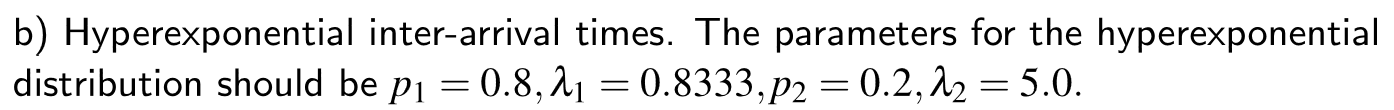

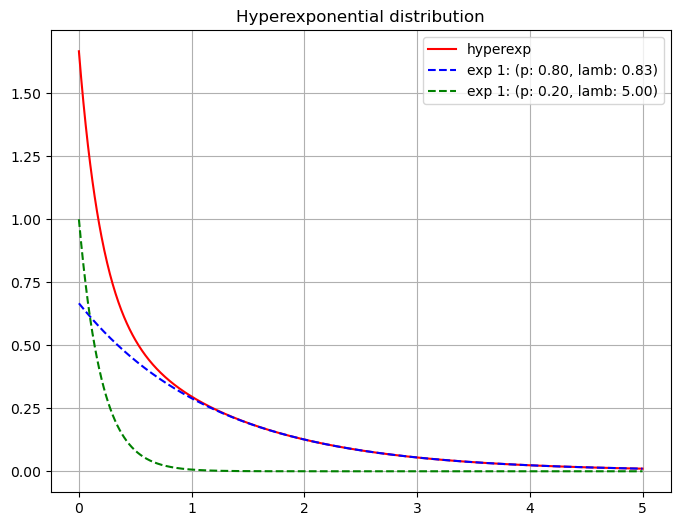

In [167]:
### Plotting hyperexponential distribution

# Setting params
p1 = 0.8
lambda1 = 0.8333
p2=0.2
lambda2 = 5

hyperexp_vars = p1*sp.stats.expon.pdf(xgrid, scale=1/lambda1) + p2*sp.stats.expon.pdf(xgrid, scale=1/lambda2)

xgrid = np.linspace(0,5,1000)

#Create figure
fig, axs = plt.subplots(1,1, figsize=(8,6))

axs.plot(xgrid, hyperexp_vars, label=f'hyperexp', color='red')
axs.plot(xgrid, p1*sp.stats.expon.pdf(xgrid, scale=1/lambda1), label=f'exp 1: (p: {p1:.2f}, lamb: {lambda1:.2f})', color='blue', linestyle='--')
axs.plot(xgrid, p2*sp.stats.expon.pdf(xgrid, scale=1/lambda2), label=f'exp 1: (p: {p2:.2f}, lamb: {lambda2:.2f})', color='green', linestyle='--')


axs.legend()
axs.grid()
axs.set_title("Hyperexponential distribution")

plt.show()

In [ ]:
#NOT DONE!
def block_system_hyperexp(n_customers=1e4, n_subsamples=10, t_mean_service=8, p1=0.8, lamb1=0.8333, p2=0.2, lamb2=5):

    # Initialise result lists
    t_res = []
    blocked_frac_res = []
    departures_res =  []

    #loop over subsamples
    for _ in range(n_subsamples):
        #State variables
        departures = []              #list of departure times for custormers currently being serviced 
        count_blocked = 0           #Counter for blocked customers
        t = 0                       #clock time
        t_arrival = 0               #arrival time (initialise as zero)

        # loop through all customers encounters
        for _ in range(int(n_customers)):
            #update time
            t += t_arrival

            #Update departure list if not empty: keep only customers in list, whose departure time > current time
            if len(departures) != 0:
                departures = [dep for dep in departures if dep > t]

            #Check whether capacity full. 
            # If full, block customer
            if len(departures) >= 10:
                count_blocked += 1                                      #increase block counter
            #If not full, assign service time and add customer to departure list
            else:
                #Assign service time for current customer
                t_service = np.random.exponential(t_mean_service)      #NB: np.randdom.exp takes mean as param
                #Add customers departure time to departure list
                departures.append(t+t_service)

            #Assign arrival time to next costumer
            t_arrival = np.random.exponential(t_mean_customers)
        
        #Store results
        t_res.append(t)
        blocked_frac_res.append(count_blocked/n_customers)
        departures_res.append(departures)

    return np.array(blocked_frac_res), np.array(t_res), departures_res